<a href="https://colab.research.google.com/github/write2chrischacko/Healthcare-Appointment-No-Show-Analysis-and-Prediction/blob/main/Healthcare_noshow_Bivariate_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import all Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set clean plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f6'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries ready!")

Libraries ready!


Upload and Load the Csv File

In [ ]:
from google.colab import files
import io

uploaded = files.upload()   # click Choose Files → select CSV

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Saving MedicalAppointment.csv to MedicalAppointment (1).csv
Shape: 110,527 rows × 14 columns


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No


Clean the Data

In [ ]:
# Parse date columns (currently stored as text strings)
df['ScheduledDay']   = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Fix column name typos
df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap':      'Handicap',
    'No-show':      'NoShow'
}, inplace=True)

# Convert target to 1 (no-show) and 0 (showed up)
df['target'] = (df['NoShow'] == 'Yes').astype(int)

# Drop the one row with impossible age = -1
df = df[df['Age'] >= 0].copy()

print("Missing values:", df.isnull().sum().sum())
print(f"No-show rate: {df['target'].mean():.2%}")

Missing values: 0
No-show rate: 20.19%


Feature Engineering for analysis

In [ ]:
# Lead time: days between booking and appointment
df['lead_time'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['lead_time'] = df['lead_time'].clip(lower=0)  # fix negatives

# Group lead_time into buckets
df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=[-1, 0, 7, 14, 30, 60, 200],
    labels=['Same-day','1-7d','8-14d','15-30d','31-60d','60d+']
)

# Group age into bins
df['age_bin'] = pd.cut(
    df['Age'],
    bins=[0,10,20,30,40,50,60,70,80,120],
    labels=['0-10','11-20','21-30','31-40','41-50',
            '51-60','61-70','71-80','80+']
)

# Extract day of week from appointment date
df['DayOfWeek'] = df['AppointmentDay'].dt.day_name()

print("New columns:", ['lead_time','lead_time_bin','age_bin','DayOfWeek'])
df[['lead_time','lead_time_bin','age_bin','DayOfWeek']].head(3)

New columns: ['lead_time', 'lead_time_bin', 'age_bin', 'DayOfWeek']


,lead_time,lead_time_bin,age_bin,DayOfWeek
0,0,Same-day,61-70,Friday
1,0,Same-day,51-60,Friday
2,0,Same-day,61-70,Friday


# Bi-Variate categorical features(Bar chart +Chi-squre)



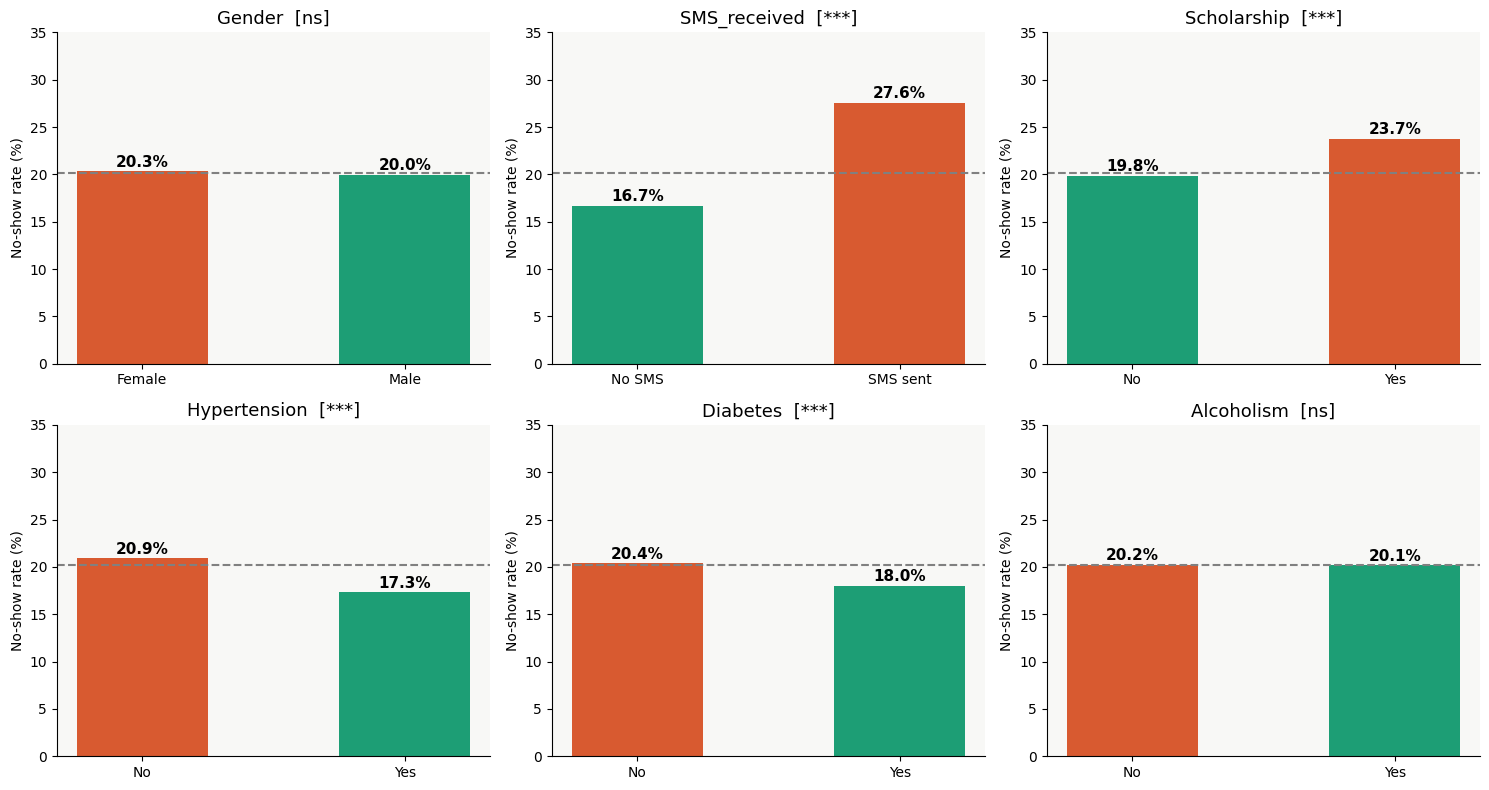

In [ ]:
BASELINE = df['target'].mean() * 100  # 20.2%

features = {
    'Gender':       {'F':'Female', 'M':'Male'},
    'SMS_received': {0:'No SMS', 1:'SMS sent'},
    'Scholarship':  {0:'No', 1:'Yes'},
    'Hypertension': {0:'No', 1:'Yes'},
    'Diabetes':     {0:'No', 1:'Yes'},
    'Alcoholism':   {0:'No', 1:'Yes'},
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, lmap) in enumerate(features.items()):
    ax = axes[i]

    # Calculate no-show rate per group
    grp = df.groupby(col)['target'].mean() * 100
    grp.index = [str(lmap.get(k, k)) for k in grp.index]

    # Chi-square significance test
    ct = pd.crosstab(df[col], df['target'])
    _, p, _, _ = stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else 'ns')

    colors = ['#D85A30' if v > BASELINE else '#1D9E75' for v in grp]
    bars = ax.bar(grp.index, grp.values, color=colors, width=0.5)
    ax.axhline(BASELINE, color='gray', linestyle='--', linewidth=1.5)

    for bar, v in zip(bars, grp.values):
        ax.text(bar.get_x() + bar.get_width()/2, v+0.5,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

    ax.set_title(f'{col}  [{sig}]', fontsize=13)
    ax.set_ylabel('No-show rate (%)')
    ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('categorical_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

Bi-variate - Lead time vs No-show

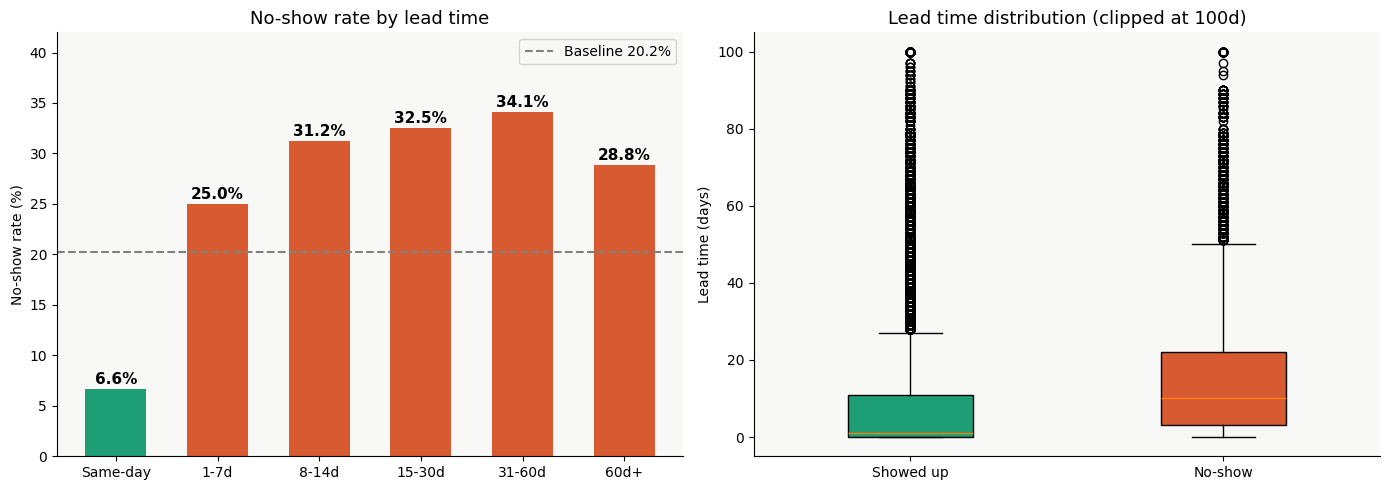

In [ ]:
# ── Rate by lead time bin ───────────────────────────────
lt = df.groupby('lead_time_bin', observed=True)['target'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — no-show rate per bucket
colors = ['#D85A30' if v > BASELINE else '#1D9E75' for v in lt]
bars = axes[0].bar(lt.index.astype(str), lt.values, color=colors, width=0.6)
axes[0].axhline(BASELINE, color='gray', linestyle='--', linewidth=1.5,
               label=f'Baseline {BASELINE:.1f}%')
for bar, v in zip(bars, lt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('No-show rate by lead time', fontsize=13)
axes[0].set_ylabel('No-show rate (%)')
axes[0].set_ylim(0, 42)
axes[0].legend()

# Box plot — lead time distribution: showed vs no-show
show_lt   = df[df['target']==0]['lead_time'].clip(upper=100)
noshow_lt = df[df['target']==1]['lead_time'].clip(upper=100)
bp = axes[1].boxplot([show_lt, noshow_lt],
              labels=['Showed up', 'No-show'],
              patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('#1D9E75')
bp['boxes'][1].set_facecolor('#D85A30')
axes[1].set_title('Lead time distribution (clipped at 100d)', fontsize=13)
axes[1].set_ylabel('Lead time (days)')

plt.tight_layout()
plt.savefig('leadtime_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

Bivariate - age vs noshow(bar+kde)

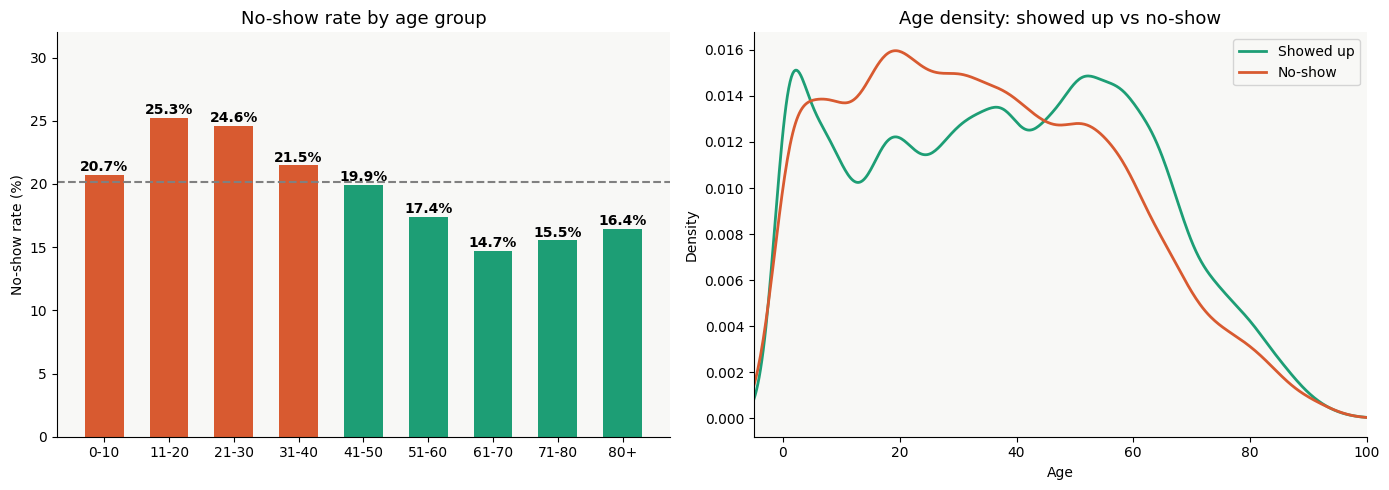

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — no-show rate per age group
age = df.groupby('age_bin', observed=True)['target'].mean() * 100
colors = ['#D85A30' if v > BASELINE else '#1D9E75' for v in age]
bars = axes[0].bar(age.index.astype(str), age.values, color=colors, width=0.6)
axes[0].axhline(BASELINE, color='gray', linestyle='--', linewidth=1.5)
for bar, v in zip(bars, age.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('No-show rate by age group', fontsize=13)
axes[0].set_ylabel('No-show rate (%)')
axes[0].set_ylim(0, 32)

# KDE — age distribution: showed vs no-show
# .plot.kde() draws a smooth density curve
df[df['target']==0]['Age'].plot.kde(ax=axes[1], color='#1D9E75',
                                    label='Showed up', linewidth=2)
df[df['target']==1]['Age'].plot.kde(ax=axes[1], color='#D85A30',
                                    label='No-show', linewidth=2)
axes[1].set_title('Age density: showed up vs no-show', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_xlim(-5, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig('age_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

Bivariate - day_of_the_week vs noshow

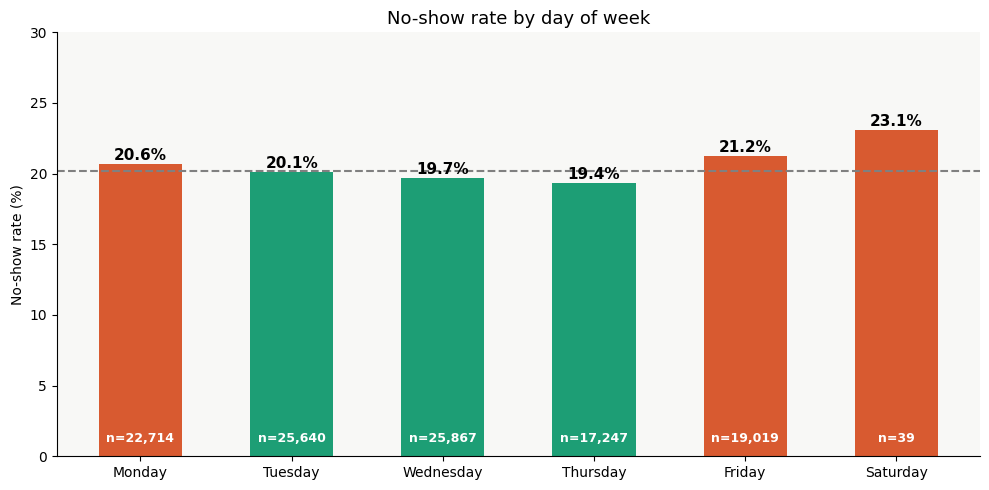

In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

dow = (df.groupby('DayOfWeek')['target']
         .agg(['mean','count'])
         .reindex(day_order))   # force Mon-Sat order
dow['mean'] = dow['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#D85A30' if v > BASELINE else '#1D9E75' for v in dow['mean']]
bars = ax.bar(dow.index, dow['mean'], color=colors, width=0.55)
ax.axhline(BASELINE, color='gray', linestyle='--', linewidth=1.5)

for bar, v, cnt in zip(bars, dow['mean'], dow['count']):
    # Rate label on top of bar
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3,
            f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    # Count label inside bar (n=...)
    ax.text(bar.get_x()+bar.get_width()/2, 1,
            f'n={cnt:,}', ha='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('No-show rate by day of week', fontsize=13)
ax.set_ylabel('No-show rate (%)')
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig('dayofweek_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

Bivariate - neighbourhood vs noshow


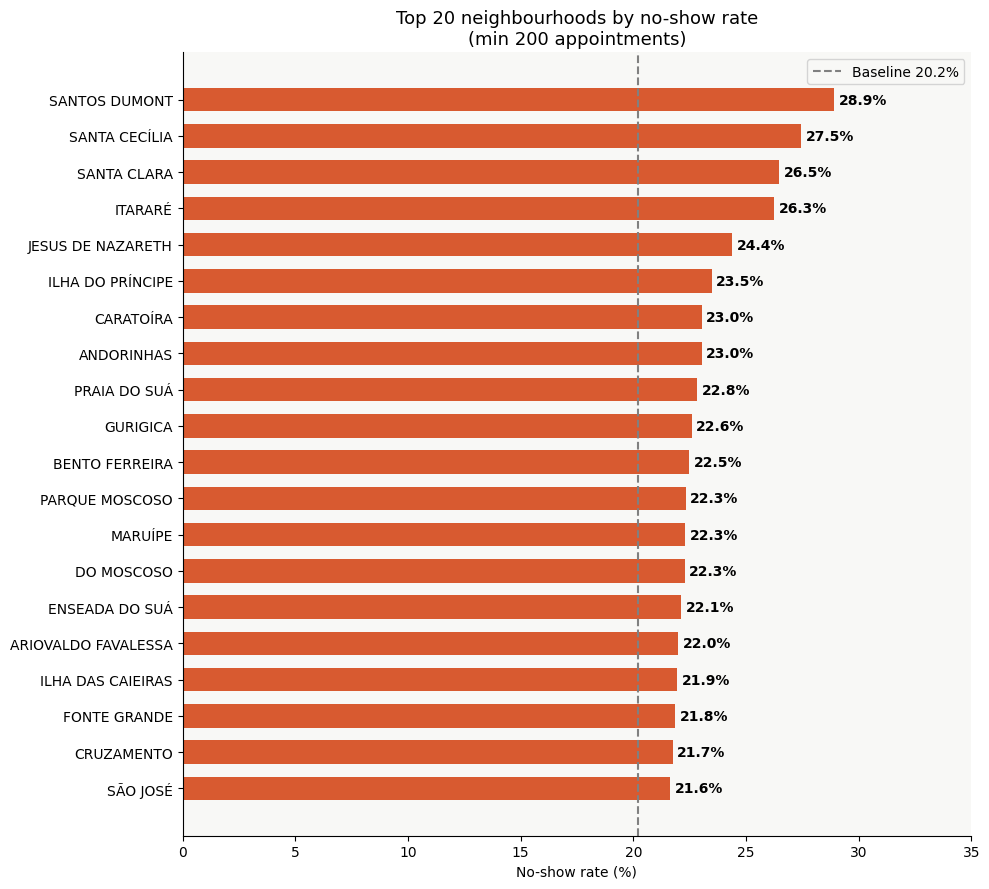

In [ ]:
neigh = (
    df.groupby('Neighbourhood')['target']
    .agg(['mean','count'])
    .query('count >= 200')          # only neighbourhoods with enough data
    .sort_values('mean', ascending=True)
    .tail(20)                        # top 20 highest no-show rate
    .reset_index()
)
neigh['mean'] = neigh['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#D85A30' if v > BASELINE else '#1D9E75' for v in neigh['mean']]

# barh = horizontal bar chart (good for long category names)
bars = ax.barh(neigh['Neighbourhood'], neigh['mean'], color=colors, height=0.65)
ax.axvline(BASELINE, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline {BASELINE:.1f}%')

for bar, v in zip(bars, neigh['mean']):
    ax.text(v+0.2, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 20 neighbourhoods by no-show rate\n(min 200 appointments)', fontsize=13)
ax.set_xlabel('No-show rate (%)')
ax.set_xlim(0, 35)
ax.legend()

plt.tight_layout()
plt.savefig('neighbourhood_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

Corelation heatmap & feature ranking

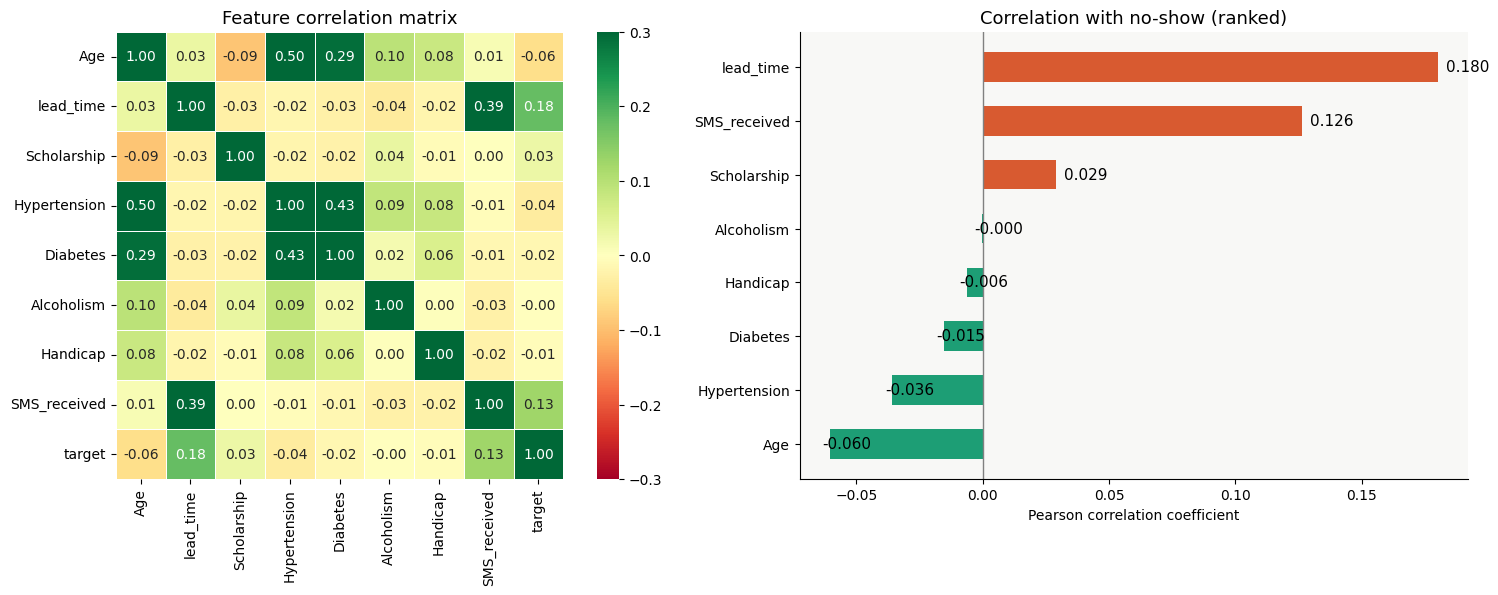

In [ ]:
numeric_cols = ['Age','lead_time','Scholarship','Hypertension',
                'Diabetes','Alcoholism','Handicap','SMS_received']

corr = df[numeric_cols + ['target']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation heatmap
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5, square=True)
axes[0].set_title('Feature correlation matrix', fontsize=13)

# Bar chart — correlation with target only (ranked)
target_corr = corr['target'].drop('target').sort_values()
colors = ['#D85A30' if v > 0 else '#1D9E75' for v in target_corr]
bars = axes[1].barh(target_corr.index, target_corr.values, color=colors, height=0.55)
axes[1].axvline(0, color='gray', linewidth=1)
for bar, v in zip(bars, target_corr.values):
    xpos = v+0.003 if v >= 0 else v-0.003
    axes[1].text(xpos, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=11)
axes[1].set_title('Correlation with no-show (ranked)', fontsize=13)
axes[1].set_xlabel('Pearson correlation coefficient')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()